# 🛡️ Cyberattack Detection Using Machine Learning

**Binary classification of network traffic as NORMAL or ATTACK using the UNSW-NB15 dataset with XGBoost.**

---

### 📋 Project Overview
- **Dataset:** UNSW-NB15 (175,341 training + 82,332 testing samples)
- **Task:** Binary classification (Normal vs Attack)
- **Model:** XGBoost Classifier
- **Baseline:** Random Forest
- **Optional:** Multiclass classification (10 attack categories)

## 1. Setup & Install Dependencies

In [10]:
!pip install xgboost --quiet

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

**Upload the CSV files** using the file upload button on the left sidebar, or clone from GitHub:

In [11]:
# Option 1: Upload files manually (run this cell, then upload when prompted)
# from google.colab import files
# uploaded = files.upload()

# Option 2: If files are already in Colab (e.g. from Google Drive or uploaded)
TRAIN_PATH = 'UNSW_NB15_training-set.csv'
TEST_PATH = 'UNSW_NB15_testing-set.csv'

# Check if files exist
if not os.path.exists(TRAIN_PATH):
    print('⚠️ CSV files not found! Please upload them.')
    print('Click the 📁 folder icon on the left sidebar → Upload button')
    print('Upload: UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv')
else:
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    print(f'✅ Training set loaded: {train_df.shape}')
    print(f'✅ Testing set loaded:  {test_df.shape}')

✅ Training set loaded: (175341, 45)
✅ Testing set loaded:  (82332, 45)


## 3. Dataset Inspection

In [12]:
print('=' * 60)
print('DATASET INSPECTION')
print('=' * 60)

print(f'\nTraining shape: {train_df.shape}')
print(f'Testing shape:  {test_df.shape}')

print(f'\n--- Column Names ({len(train_df.columns)}) ---')
for i, col in enumerate(train_df.columns):
    dtype = train_df[col].dtype
    print(f'  {i:2d}. {col:<25s} {str(dtype):<10s}')

print(f'\n--- Missing Values ---')
print(f'Training: {train_df.isnull().sum().sum()}')
print(f'Testing:  {test_df.isnull().sum().sum()}')

print(f'\n--- Duplicate Rows ---')
print(f'Training: {train_df.duplicated().sum()}')
print(f'Testing:  {test_df.duplicated().sum()}')

print(f'\n--- Target Distribution (label) ---')
print('Training:')
print(train_df['label'].value_counts())
print('\nTesting:')
print(test_df['label'].value_counts())

print(f'\n--- Categorical Columns ---')
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f'  {col}: {train_df[col].nunique()} unique values')

DATASET INSPECTION

Training shape: (175341, 45)
Testing shape:  (82332, 45)

--- Column Names (45) ---
   0. id                        int64     
   1. dur                       float64   
   2. proto                     object    
   3. service                   object    
   4. state                     object    
   5. spkts                     int64     
   6. dpkts                     int64     
   7. sbytes                    int64     
   8. dbytes                    int64     
   9. rate                      float64   
  10. sttl                      int64     
  11. dttl                      int64     
  12. sload                     float64   
  13. dload                     float64   
  14. sloss                     int64     
  15. dloss                     int64     
  16. sinpkt                    float64   
  17. dinpkt                    float64   
  18. sjit                      float64   
  19. djit                      float64   
  20. swin                      int6

In [13]:
# First 5 rows
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [14]:
# Statistical summary
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


## 4. Preprocessing

In [15]:
# Columns to drop and target columns
DROP_COLS = ['id']           # Row identifier - no predictive value
TARGET_COL = 'label'         # Binary target: 0=Normal, 1=Attack
MULTICLASS_COL = 'attack_cat'  # Multiclass target (saved for later)
RANDOM_STATE = 42

# Save multiclass target for optional extension
train_attack_cat = train_df[MULTICLASS_COL].copy()
test_attack_cat = test_df[MULTICLASS_COL].copy()

# Separate features and target
X_train = train_df.drop(columns=DROP_COLS + [TARGET_COL, MULTICLASS_COL])
y_train = train_df[TARGET_COL].values
X_test = test_df.drop(columns=DROP_COLS + [TARGET_COL, MULTICLASS_COL])
y_test = test_df[TARGET_COL].values

print(f'Features: {X_train.shape[1]}')
print(f'Training: Normal={sum(y_train==0):,} | Attack={sum(y_train==1):,}')
print(f'Testing:  Normal={sum(y_test==0):,} | Attack={sum(y_test==1):,}')

# Identify column types
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f'\nCategorical ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical: {len(numerical_cols)} columns')

Features: 42
Training: Normal=56,000 | Attack=119,341
Testing:  Normal=37,000 | Attack=45,332

Categorical (3): ['proto', 'service', 'state']
Numerical: 39 columns


In [16]:
# Build preprocessing pipeline using scikit-learn ColumnTransformer
# This ensures reproducibility and prevents data leakage

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='drop'
)

# Fit on training data ONLY (no data leakage!)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

all_feature_names = numerical_cols + categorical_cols

print(f'Processed shape: {X_train_processed.shape}')
print('Preprocessing complete!')

Processed shape: (175341, 42)
Preprocessing complete!


## 5. Class Distribution Visualization

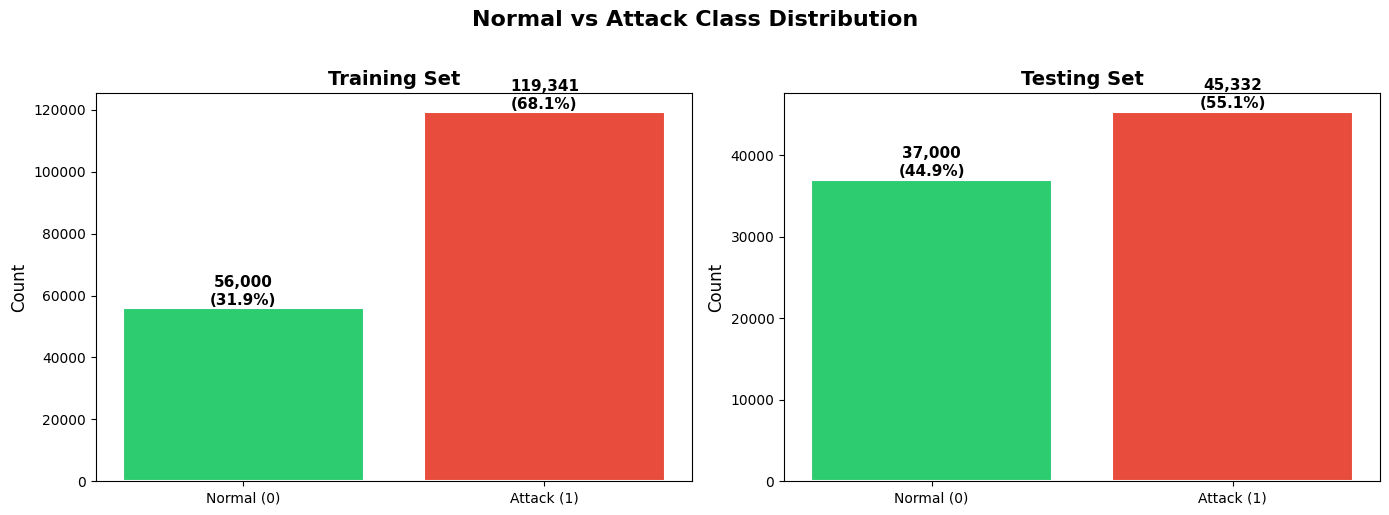

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
labels = ['Normal (0)', 'Attack (1)']

# Training
train_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(labels, train_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(y_train)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# Testing
test_counts = pd.Series(y_test).value_counts().sort_index()
axes[1].bar(labels, test_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Testing Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 500, f'{v:,}\n({v/len(y_test)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Normal vs Attack Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Baseline Model — Random Forest

In [18]:
rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)
rf_time = time.time() - rf_start

rf_pred = rf_model.predict(X_test_processed)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f'Random Forest Results:')
print(f'  Accuracy: {rf_acc:.4f}')
print(f'  F1 Score: {rf_f1:.4f}')
print(f'  Training Time: {rf_time:.1f}s')

Random Forest Results:
  Accuracy: 0.8704
  F1 Score: 0.8936
  Training Time: 45.4s


## 7. Main Model — XGBoost Classifier

In [19]:
xgb_start = time.time()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    tree_method='hist'
)

xgb_model.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=False
)
xgb_time = time.time() - xgb_start

print(f'XGBoost trained in {xgb_time:.1f}s')

XGBoost trained in 16.2s


## 8. Evaluation on Official Test Set

In [20]:
y_pred = xgb_model.predict(X_test_processed)
y_pred_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
fpr_val = FP / (FP + TN)
fnr_val = FN / (FN + TP)

print('=' * 50)
print('XGBOOST EVALUATION RESULTS')
print('=' * 50)
print(f'Accuracy:           {accuracy:.4f}')
print(f'Precision:          {precision:.4f}')
print(f'Recall:             {recall:.4f}')
print(f'F1 Score:           {f1:.4f}')
print(f'ROC-AUC:            {roc_auc:.4f}')
print(f'False Positive Rate: {fpr_val:.4f}')
print(f'False Negative Rate: {fnr_val:.4f}')
print(f'\nConfusion Matrix:')
print(f'  TN={TN:,}  FP={FP:,}')
print(f'  FN={FN:,}  TP={TP:,}')

XGBOOST EVALUATION RESULTS
Accuracy:           0.8728
Precision:          0.8224
Recall:             0.9808
F1 Score:           0.8946
ROC-AUC:            0.9830
False Positive Rate: 0.2595
False Negative Rate: 0.0192

Confusion Matrix:
  TN=27,397  FP=9,603
  FN=871  TP=44,461


In [21]:
# Full Classification Report
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       0.97      0.74      0.84     37000
      Attack       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332



In [22]:
# Model Comparison
comparison = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'XGBoost (Main)'],
    'Accuracy': [rf_acc, accuracy],
    'F1 Score': [rf_f1, f1],
    'Training Time (s)': [rf_time, xgb_time]
})
comparison.style.highlight_max(subset=['Accuracy', 'F1 Score'], color='lightgreen')

,Model,Accuracy,F1 Score,Training Time (s)
0,Random Forest (Baseline),0.870427,0.893571,45.442191
1,XGBoost (Main),0.872783,0.894624,16.227932


## 9. Visualizations

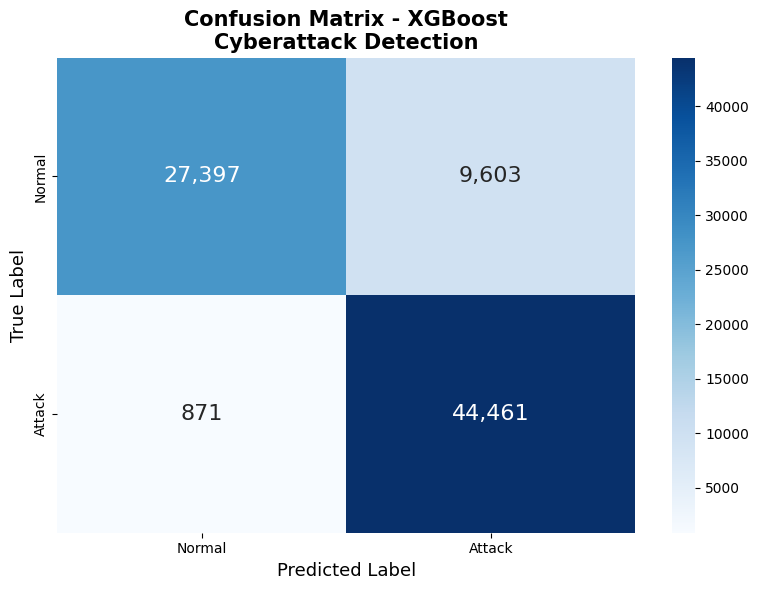

In [23]:
# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            annot_kws={'size': 16}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix - XGBoost\nCyberattack Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

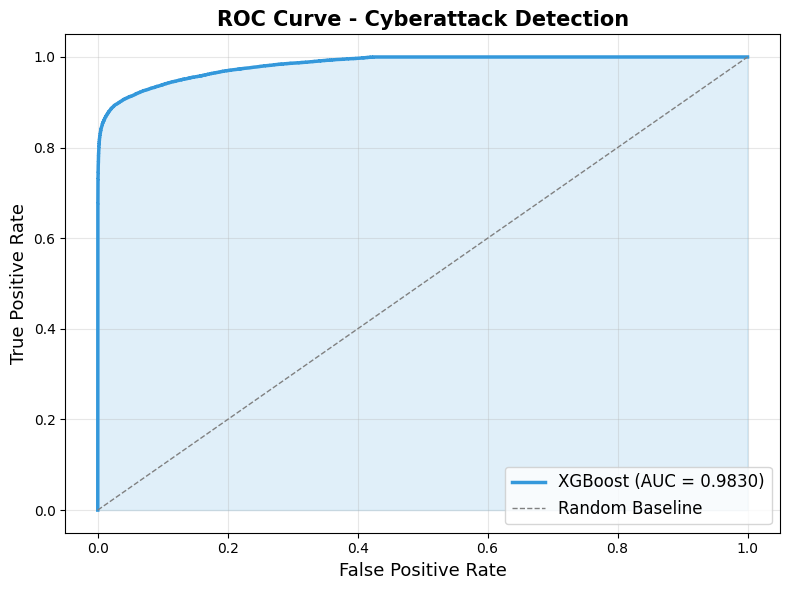

In [24]:
# ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_curve, tpr_curve, color='#3498db', linewidth=2.5,
        label=f'XGBoost (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle='--', label='Random Baseline')
ax.fill_between(fpr_curve, tpr_curve, alpha=0.15, color='#3498db')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve - Cyberattack Detection', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

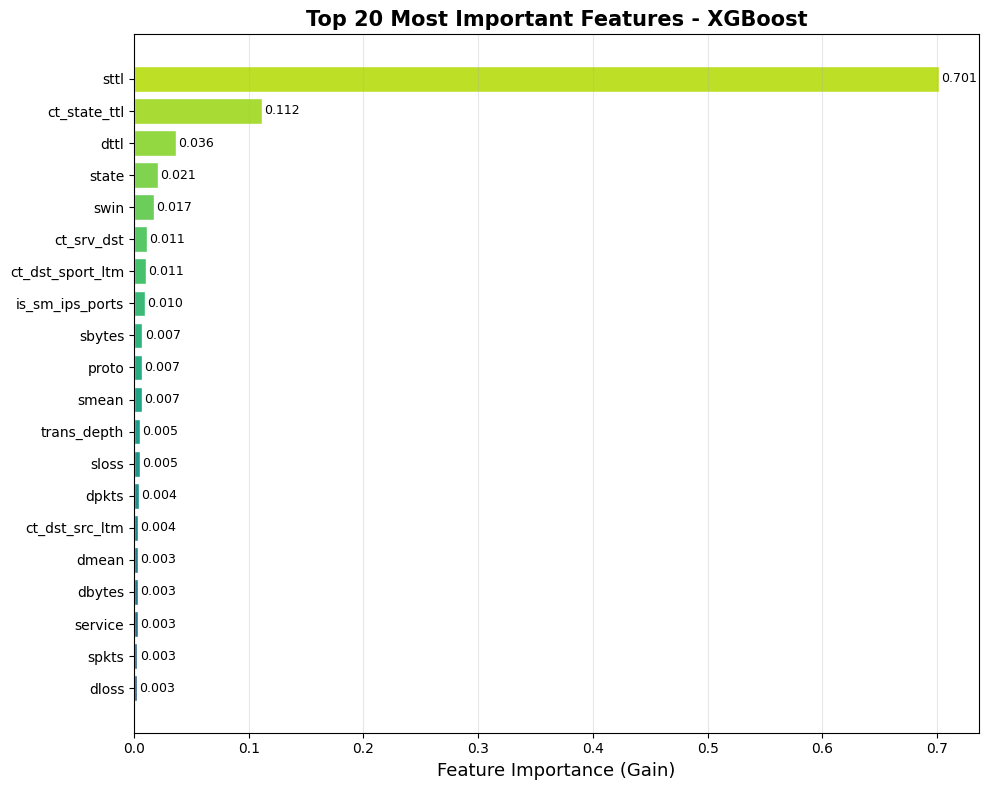

In [25]:
# Feature Importance - Top 20
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

top_n = 20
top_features = importance_df.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_features['Feature'], top_features['Importance'],
               color=plt.cm.viridis(np.linspace(0.3, 0.9, top_n)), edgecolor='white')
ax.set_xlabel('Feature Importance (Gain)', fontsize=13)
ax.set_title(f'Top {top_n} Most Important Features - XGBoost', fontsize=15, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, top_features['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Prediction Demo

In [26]:
def predict_sample(sample_df, preprocessor, model):
    """Predict whether a network traffic sample is NORMAL or ATTACK."""
    sample_processed = preprocessor.transform(sample_df)
    pred = model.predict(sample_processed)[0]
    proba = model.predict_proba(sample_processed)[0]
    label = 'ATTACK' if pred == 1 else 'NORMAL'
    confidence = max(proba) * 100
    return label, confidence, proba

print('=' * 50)
print('PREDICTION DEMO')
print('=' * 50)

for idx in [0, 100, 500, 1000, 5000]:
    sample = X_test.iloc[[idx]]
    label, confidence, proba = predict_sample(sample, preprocessor, xgb_model)
    actual = 'ATTACK' if y_test[idx] == 1 else 'NORMAL'
    status = '✅' if label == actual else '❌'
    print(f'\nSample #{idx}: {status}')
    print(f'  Prediction: {label} (confidence: {confidence:.1f}%)')
    print(f'  Actual:     {actual}')
    print(f'  P(Normal)={proba[0]:.4f} | P(Attack)={proba[1]:.4f}')

PREDICTION DEMO

Sample #0: ❌
  Prediction: ATTACK (confidence: 89.2%)
  Actual:     NORMAL
  P(Normal)=0.1076 | P(Attack)=0.8924

Sample #100: ✅
  Prediction: NORMAL (confidence: 99.8%)
  Actual:     NORMAL
  P(Normal)=0.9979 | P(Attack)=0.0021

Sample #500: ✅
  Prediction: ATTACK (confidence: 100.0%)
  Actual:     ATTACK
  P(Normal)=0.0000 | P(Attack)=1.0000

Sample #1000: ✅
  Prediction: ATTACK (confidence: 99.6%)
  Actual:     ATTACK
  P(Normal)=0.0042 | P(Attack)=0.9958

Sample #5000: ✅
  Prediction: ATTACK (confidence: 100.0%)
  Actual:     ATTACK
  P(Normal)=0.0000 | P(Attack)=1.0000


## 11. Cybersecurity Analysis

### Why Recall and False Negative Rate matter:

- A **False Negative** = the system classifies an **ATTACK** as **NORMAL**
- This means the attack goes **UNDETECTED** and can cause:
  - 🔴 Data breaches and data exfiltration
  - 🔴 Ransomware deployment
  - 🔴 Network compromise and lateral movement
  - 🔴 Financial loss and regulatory penalties

**In cybersecurity, MISSING AN ATTACK is far more dangerous than a false alarm.**

We prioritize **HIGH RECALL** (catching as many attacks as possible).

In [27]:
print(f'Our Recall:             {recall:.4f} ({recall*100:.1f}%)')
print(f'Our False Negative Rate: {fnr_val:.4f} ({fnr_val*100:.2f}%)')
print(f'\nOut of {sum(y_test==1):,} actual attacks:')
print(f'  Detected: {TP:,} attacks')
print(f'  Missed:   {FN:,} attacks')
print(f'\n{recall*100:.1f}% of all attacks are successfully detected!')

Our Recall:             0.9808 (98.1%)
Our False Negative Rate: 0.0192 (1.92%)

Out of 45,332 actual attacks:
  Detected: 44,461 attacks
  Missed:   871 attacks

98.1% of all attacks are successfully detected!


## 12. Final Report

In [28]:
print('=' * 60)
print('CYBERATTACK DETECTION RESULTS')
print('-' * 60)
print(f'Dataset:            UNSW-NB15')
print(f'Training Samples:   {len(y_train):,}')
print(f'Testing Samples:    {len(y_test):,}')
print(f'Number of Features: {X_train_processed.shape[1]}')
print()
print(f'Model:              XGBoost Classifier')
print(f'Training Time:      {xgb_time:.1f}s')
print()
print(f'Accuracy:           {accuracy:.4f}')
print(f'Precision:          {precision:.4f}')
print(f'Recall:             {recall:.4f}')
print(f'F1 Score:           {f1:.4f}')
print(f'ROC-AUC:            {roc_auc:.4f}')
print()
print(f'False Positive Rate: {fpr_val:.4f}')
print(f'False Negative Rate: {fnr_val:.4f}')
print()
print(f'Confusion Matrix:')
print(f'                 Predicted Normal  Predicted Attack')
print(f'  Actual Normal      {TN:>10,}      {FP:>10,}')
print(f'  Actual Attack      {FN:>10,}      {TP:>10,}')
print('=' * 60)

CYBERATTACK DETECTION RESULTS
------------------------------------------------------------
Dataset:            UNSW-NB15
Training Samples:   175,341
Testing Samples:    82,332
Number of Features: 42

Model:              XGBoost Classifier
Training Time:      16.2s

Accuracy:           0.8728
Precision:          0.8224
Recall:             0.9808
F1 Score:           0.8946
ROC-AUC:            0.9830

False Positive Rate: 0.2595
False Negative Rate: 0.0192

Confusion Matrix:
                 Predicted Normal  Predicted Attack
  Actual Normal          27,397           9,603
  Actual Attack             871          44,461


## 13. Save Model

In [29]:
# Save complete pipeline
full_pipeline = {
    'preprocessor': preprocessor,
    'model': xgb_model,
    'feature_columns': list(X_train.columns),
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols,
}

joblib.dump(full_pipeline, 'cyberattack_model.pkl')
print('Model saved to cyberattack_model.pkl')

Model saved to cyberattack_model.pkl


---

## 14. (Optional) Multiclass Classification

Classify attacks into specific categories: Generic, Exploits, Fuzzers, DoS, Reconnaissance, Analysis, Backdoor, Shellcode, Worms

In [30]:
from sklearn.preprocessing import LabelEncoder

# Encode multiclass target
le = LabelEncoder()
y_train_multi = le.fit_transform(train_attack_cat.str.strip())
y_test_multi = le.transform(test_attack_cat.str.strip())
class_names = le.classes_

print(f'Classes ({len(class_names)}): {list(class_names)}')

# Train multiclass XGBoost
xgb_multi = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=RANDOM_STATE, eval_metric='mlogloss',
    use_label_encoder=False, n_jobs=-1, tree_method='hist',
    objective='multi:softprob', num_class=len(class_names)
)

xgb_multi.fit(X_train_processed, y_train_multi,
              eval_set=[(X_test_processed, y_test_multi)], verbose=False)

y_pred_multi = xgb_multi.predict(X_test_processed)
multi_acc = accuracy_score(y_test_multi, y_pred_multi)
print(f'\nMulticlass Accuracy: {multi_acc:.4f}')
print(f'\n{classification_report(y_test_multi, y_pred_multi, target_names=class_names)}')

Classes (10): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

Multiclass Accuracy: 0.7685

                precision    recall  f1-score   support

      Analysis       0.04      0.07      0.05       677
      Backdoor       0.03      0.06      0.04       583
           DoS       0.58      0.10      0.17      4089
      Exploits       0.60      0.87      0.71     11132
       Fuzzers       0.31      0.60      0.41      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.76      0.85     37000
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.36      0.79      0.50       378
         Worms       0.68      0.34      0.45        44

      accuracy                           0.77     82332
     macro avg       0.55      0.54      0.50     82332
  weighted avg       0.84      0.77      0.78     82332



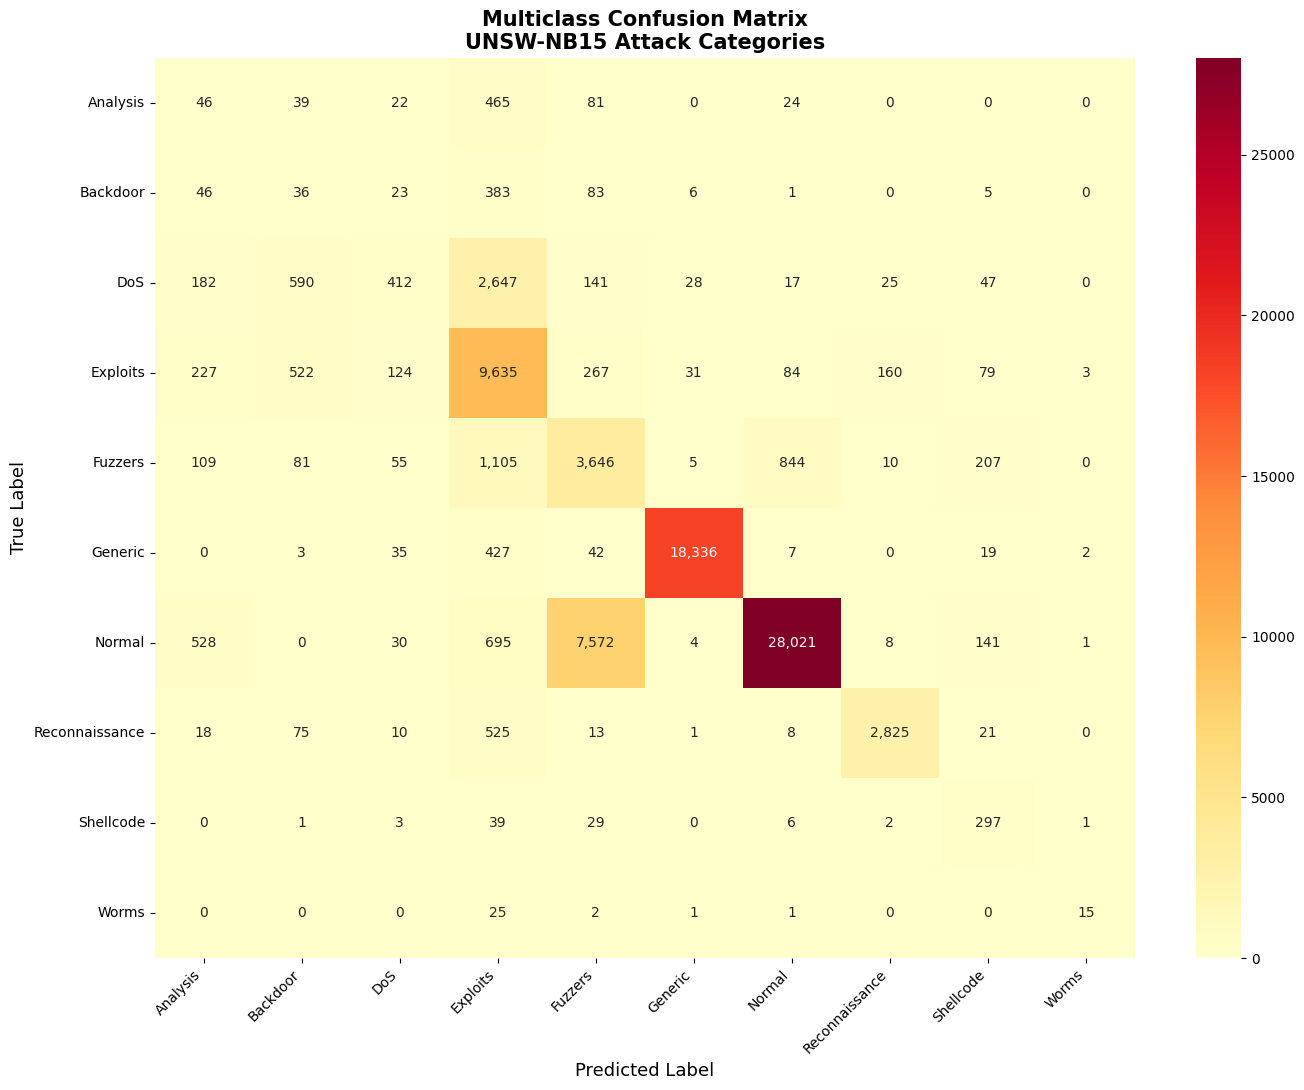

In [31]:
# Multiclass Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_multi, annot=True, fmt=',d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 10}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Multiclass Confusion Matrix\nUNSW-NB15 Attack Categories', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()